# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [9]:
from imports import *
from vectorized_model import VectorizedModel
import matplotlib.pyplot as plt

## Try with Bayes Agent (Vectorized)

In [10]:
n_agents = 1000
my_network = nx.gnp_random_graph(n_agents, p=0.1, directed=True)

In [11]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,tstep_stopping=True,directed_network = True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

100%|██████████| 10000/10000 [00:15<00:00, 641.26it/s]


steps:  10000
conclusion:  1.0
conclusion core 1.0


,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,0.884987,0.077005,0.155840,0.168365,0.376929,0.356775,0.785807,0.426370,0.627997,0.897830,...,0.548342,0.325414,0.855667,0.182340,0.139772,0.470357,0.263356,0.520430,0.868979,0.298119
1,0.888205,0.069931,0.155840,0.155347,0.375052,0.345837,0.807808,0.403073,0.605308,0.889470,...,0.500493,0.304703,0.865269,0.159685,0.139772,0.506322,0.239286,0.528411,0.870790,0.281654
2,0.882522,0.064903,0.162259,0.129966,0.371309,0.331504,0.810280,0.414674,0.578259,0.886285,...,0.476510,0.273487,0.856652,0.143248,0.125079,0.512320,0.251130,0.520430,0.872580,0.270464


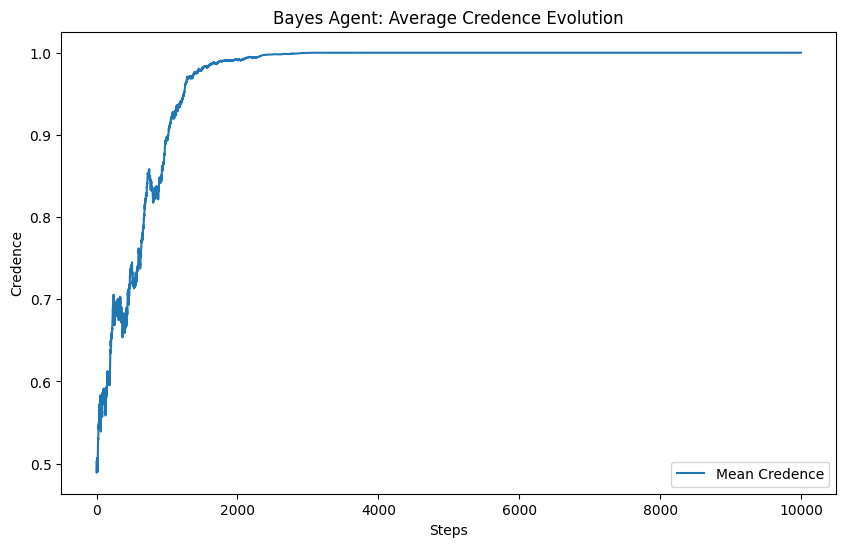

In [12]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [13]:
n_agents = 1000
my_network = nx.gnp_random_graph(n_agents, p=0.1, directed=True)

In [14]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,tstep_stopping=True,directed_network = True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

100%|██████████| 10000/10000 [00:29<00:00, 337.91it/s]


steps:  10000
conclusion:  0.946


,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,"[0.00012841534790181976, 0.8355728882169317]","[0.24225755253514392, 0.9305039973464654]","[0.36152765617902916, 0.0051147360204691576]","[0.865944138019661, 5.65803150795003e-07]","[0.12714012826959223, 0.005928683681345603]","[0.7578103463344665, 0.0073853470682562145]","[0.09357488066425454, 0.4317800611205367]","[0.14755762411721463, 0.1885237540708151]","[0.8705614210139849, 0.8237302611866002]","[0.28406455028439714, 0.7716994893739965]",...,"[0.6326753373268489, 0.8423681969101706]","[0.5006422651384513, 0.5655506483703603]","[0.9990659995969046, 0.944708968905751]","[0.6863254040713612, 0.022260962495017366]","[0.6796746806198726, 0.9998320289517578]","[0.7098461405205292, 0.6893834230197199]","[0.7729761512095781, 7.71526513720885e-06]","[0.15391523409027932, 1.0]","[0.6280380531125065, 0.6880193513603917]","[0.0605133609178911, 0.4956240068478237]"
1,"[0.5006400975573728, 0.4892558505282051]","[0.4917142148666796, 0.4753410380864375]","[0.4807281933099833, 0.47002912844339034]","[0.5221544458228081, 0.44797402335479086]","[0.5267761751194677, 0.4944304643041603]","[0.4993013592102064, 0.4593891165480365]","[0.48272013356537236, 0.5434645552382485]","[0.5239338401559267, 0.5002384875546585]","[0.4915084210724607, 0.5059565481972848]","[0.5002182967558175, 0.5088367460287159]",...,"[0.4861175251825452, 0.4835533004850396]","[0.5067053111364566, 0.43652086554710495]","[0.5054475891137431, 0.48331644740309676]","[0.42333996265368606, 0.5135552016343943]","[0.5174656827876564, 0.5213442383891512]","[0.50056723282278, 0.46412484716871455]","[0.4511953518980221, 0.4965262801924916]","[0.44911887846266885, 0.540289357622936]","[0.4744245156031234, 0.4611213745528917]","[0.5075293694272787, 0.530967369127446]"
2,"[0.503861392407535, 0.48055341205240365]","[0.4943463920967373, 0.4824632596627296]","[0.49150636649066587, 0.4814132863628278]","[0.522382386738758, 0.48022311480522795]","[0.4680047379736639, 0.5268943051302001]","[0.48898958520650165, 0.49188600440800934]","[0.5092633511512275, 0.4596228131701474]","[0.5467162529026225, 0.49191267639412434]","[0.5016742385522586, 0.461630468135337]","[0.48106645389549585, 0.4907272908461277]",...,"[0.4775693699006555, 0.45633783289321794]","[0.47926858386247434, 0.48739404050212654]","[0.4851687180209005, 0.48245224330704534]","[0.46806496099732536, 0.5014780111595681]","[0.4780133653777816, 0.45176078621145327]","[0.5083304792198231, 0.483181902060625]","[0.4904939931098099, 0.4803627234110562]","[0.45501585341448586, 0.5114468759010721]","[0.5010305364170423, 0.5068070326178112]","[0.5107551465760202, 0.5184147876432154]"


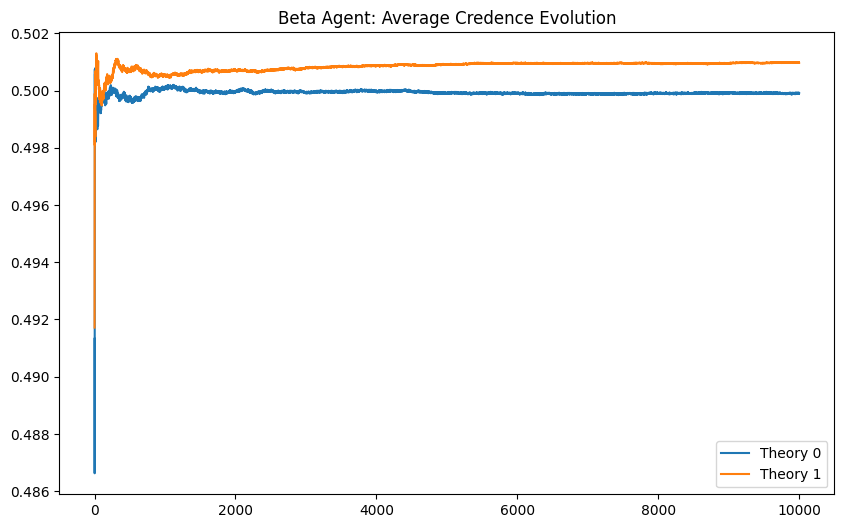

In [15]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

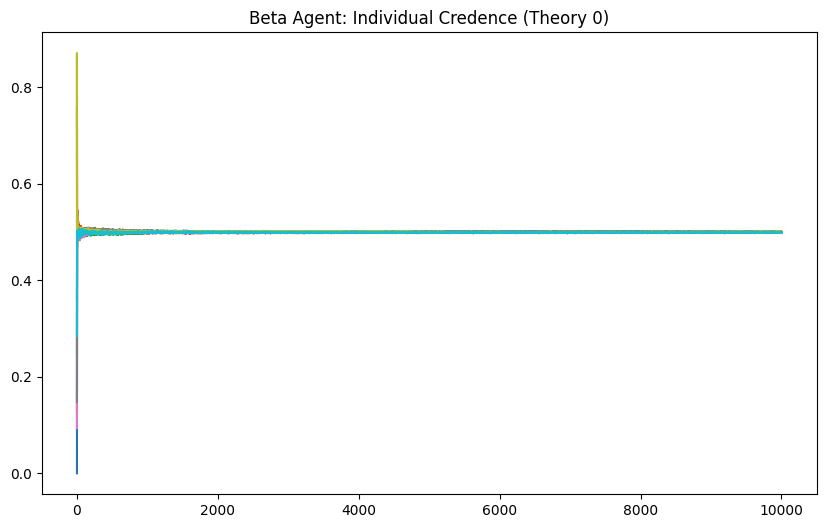

In [16]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()